# Assignment 13 Text Analytics

In this assignment, you will:
- Load and inspect a real-world business reviews dataset.
- Preprocess review text for NLP (tokenization, stopwords, lemmatization).
- Run sentiment analysis (rule-based and classifier-based) and compare to star ratings.
- Extract main topics from reviews using LDA and (optional) BERTopic.
- Interpret results in a business context (actionable insights).

## Why This Matters

Customer Reviews are critical for the survival of any business, but especially for restaurants.  Restaurants compete with not only all of the other restaurants in local area, but also with the option for customers to stay home and cook their own food.  Chefs and restaurant owners must monitor customer feedback to see if they should make changes to their pricing, menu options, restaurant amenities and seating/serving process.

You have been given 100 customer reviews.  Your job is to look for main topics that are mentioned, and whether those reviews have a postive, neutral or negative tone (sentiment).  

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_13_text_analytics.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>



## Original Source: Dataset Description

The dataset you'll be using is a set of **restaurant reviews**, available from [Kaggle](https://www.kaggle.com/datasets/pruthvirajgshitole/e-commerce-purchases-and-reviews?utm_source=chatgpt.com&select=customer_purchase_data.csv).

Each row represents one customer review. The columns include:

- **Review** - text of the customer review
- **Liked** - indicates if the customer likes (1) or does not like (0) the restaurant

Please note that some reviews have commas and apostrophes, which can prevent the record from loading correctly.  You should verify that you have 1,000 reviews total.  

## 1. Load and Preview the Data

### Do the following:
1. Import your TSV file called `Restaurant_Reviews.tsv`.  Note that TSV is for Tab Separated Values.  This file does not use commas as a delimiter.
2. Use `pandas` to load and preview the dataset
3. Verify that all 1,000 rows were imported correctly
4. Calculate the overall percentage of reviews that "Liked" the restaurant
5. Create a visualization to show the percentage of likes versus non-likes


In [1]:
import pandas as pd
import csv

# Load the reviews
url = "https://raw.githubusercontent.com/Stan-Pugsley/is_4487_base/refs/heads/main/DataSets/Restaurant_Reviews.tsv"
df = pd.read_csv(url, sep='\t', quoting=csv.QUOTE_MINIMAL)

df.head()

,Review,Liked
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1


Number of rows imported: 1000


Percentage of reviews that liked the restaurant: 50.00%


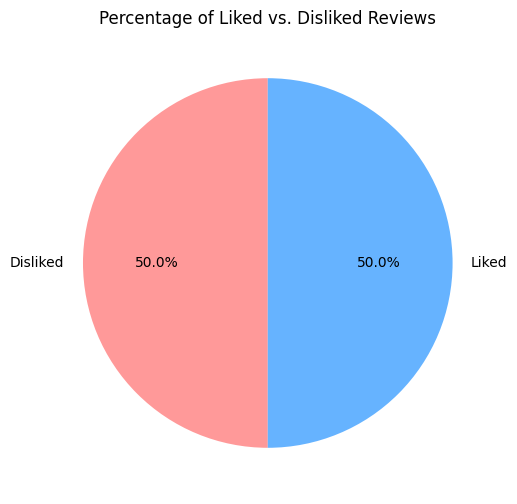

## 2. Drop Columns Not Useful for Modeling

**Business framing:**  
To do text analysis, we need to remove all of the junk in the reviews.  This would include anything like punctuation, website URLs, emojis, etc.

### Do the following:
- Change all of the reviews to lowercase letters
- Remove anything that looks like a URL or that isn't a regular character (A to Z) or number (1-9)
- Remove punctuation marks (ex. !.,-:;)

### In Your Response:
1. What risks might occur if you included the review "junk" in your model?


,Review,Liked
0,wow... loved this place.,1
1,crust is not good.,0
2,not tasty and the texture was just nasty.,0
3,stopped by during the late may bank holiday of...,1
4,the selection on the menu was great and so wer...,1


,Review,Liked
0,wow loved this place,1
1,crust is not good,0
2,not tasty and the texture was just nasty,0
3,stopped by during the late may bank holiday of...,1
4,the selection on the menu was great and so wer...,1


Leaving junk in a text analytics model could result in inaccurate, unreliable, or biased results. Since we are only analyzing text, that's all that should be in our data. Models trained on data with junk in it are not as reliable as models trained on cleaned data. Things like URL's and punctuation marks are not helpful for analysis, and so they should be taken out.

## 3. Sentiment Analysis

**Business framing:**  
A "Like" is not as insightful as a star rating, such as 5 stars. It only has two values. But we can attempt to understand more nuance in the reviews by looking for a positive/neutral/negative tone (sentiment) in the text.   Then we can compare that to the "Likes" to see if they match.  

### Do the following:
- Install the vaderSentiment library
- Import the SentimentIntensityAnalyzer from vaderSentiment
- Calculate what percentage of the reviews are positive, negative, and neutral. The total percentages should add up to 100%

### In Your Response:
1. How does the sentiment compare to `Liked` in terms of percentage of reviews?
2. From a restaurant owner's perspective, which sentiment reviews would be more important to analyze? (positive, negative or neutral)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 5.6 MB/s eta 0:00:00


Sentiment Distribution:
Sentiment
Positive    52.8%
Negative    24.2%
Neutral     23.0%
Name: proportion, dtype: object


Surprisingly, this says that 52.8% of reviews have a positive sentiment, compared to 50% that "liked" the restaurant. It is slightly higher. It is 2.8% higher to be exact.


From a restaurant owner's perspective, I would want to analyze negative reviews more. This is because I would want to identify areas that are not good so that I could work to improve them. Positve reviews are great, but they don't need the same kind of attention that negative reviews do.

## 4. Topic Analysis - Text Preprocessing

**Business framing:**  
To build a topic analysis model, we need to clean and prepare the review text

### Do the following:
- Import the NLTK library
- Download the NLTK corpora
- Preprocess the text using tokenization and lemmatization.  Be sure to remove any stopwords along the way.
- Display the first 10 processed reviews

### In Your Response:
1. What is a corpora and how is it used for text analysis?
2. What would be the tokens in the first review? "Wow... Loved this place."
3. What does lemmatization do?  How will it help in this process?


,Processed_Review
0,"[wow, loved, place]"
1,"[crust, good]"
2,"[tasty, texture, nasty]"
3,"[stopped, late, may, bank, holiday, rick, stev..."
4,"[selection, menu, great, price]"
5,"[getting, angry, want, damn, pho]"
6,"[honeslty, taste, fresh]"
7,"[potato, like, rubber, could, tell, made, ahea..."
8,"[fry, great]"
9,"[great, touch]"


A corpora is a large, structured collection of text or speech used for language analysis. It enables the identification of linguistic patterns, statistical analysis of word and phrase usage, and reserach into langauge variation and change. This includes frequency counts of words and grammar structures.


The tokens in the first review would be 'wow' ''I' 'loved' 'this' 'place.' This is because punctuation wsa removed.

Lemmatization reduces words to their base form, known as the lemma. This reduces data redundancy and greatly improves the performance of NLP models by treating different forms of a word as a single item. It simplifies NLP models.

## 5. Topic Analysis - Dictionary and Corpus

**Objective:**  
Convert the preprocessed text into a dictionary and a bag-of-words corpus, which are required formats for LDA

### Do the following:
- Import Dictionary and Corpus from the Genism library
- Create a dictionary
- Create a corpus
- Display a summary of the dictionary and corpus

### In Your Response:
1. What is a corpus and how is it useful?
2. How is a dictionary different from a corpus?

Number of unique tokens in dictionary: 249
First 5 items in dictionary (id: token):
0: loved
1: place
2: good
3: tasty
4: may


Number of unique documents in corpus: 1000
First document in corpus (word_id, frequency):
[(0, 1), (1, 1)]


A corpus is a large, structured collection of texts used in a dataset for linguistic and text analysis. It allows for things like word frequency analysis, topic modeling, and sentiment analysis. Insights can be gained by looking at a corpus that would be impossible to find with manual reading.


A corpus is a collection of natural language text data, while a dictionary is a general purpose data structure for storing words. Dictionaries are used more for data organization and structure, while a corpus is used for linguistic analysis and training NLP models. A corpus helps a NLP model understand langauge patterns. A corpus is very structured, often with metadata and annotations, while a dictionary is an unordered collection of key-value pairs.

## 6. Topic Analysis - Build LDA Model

**Objective:**  
Apply the LDA model to the corpus to identify main topics.

### Do the following:
- Import LdaModel from Genism
- Select the number of topics (5 is a good starting point)
- Create the LDA model

### In Your Response:
1. In what cases would you want to use more than 5 topics?  
2. How would you know if you have too many topics?

NOTE: You may receive an error about training "not converging".  You can ignore that error for this assignment. (Let's keep it simple)


LDA Model created successfully with 5 topics.


It would be a good idea to use more than 5 topics when a smaller number of topics results in insufficient separation, topics that are too broad, or a lack of detail. A higher number of topics is usually good for a large and diverse corpus, or a more granular analysis.

If you have too many topics, over-clustering or a high degree of topic similarity. A model with too many topics can also be difficult to label. If your topics are overlapping, you probably have too many. If the model starts to overfit your data, you likely have too many topics as well.

## 7. Summarize the Topics

**Business framing:**  
Now comes one of the most challenging steps.  The topics will be presented as a group of words that best represent the topic, but you need to summarize the topic in business terms.   

### Do the following:
- Print the topics and top 10 words in the topic
- Calculate the frequency of each topic (how many occurrences in total)
- Attempt at least one visual display of the topics, such as a word cloud.  (Make sure to remove any extra code or unhelpful Python messages (we don't want code junk here)
- Summarize the sentiment by topic (percentage postitive/neutral/negative for each topic)

### In Your Response:
1. Give each topic a 2-3 word name.  You should list the topic number and a name that you will create that summarize the words used.  For example, "Topic #1 - Slow Service"


Topic 0: 0.111*"food" + 0.099*"place" + 0.069*"good" + 0.039*"like" + 0.032*"time" + 0.031*"really" + 0.025*"one" + 0.024*"eat" + 0.022*"get" + 0.022*"experience"
Topic 1: 0.097*"back" + 0.068*"would" + 0.049*"came" + 0.045*"u" + 0.039*"bad" + 0.034*"awesome" + 0.033*"never" + 0.029*"table" + 0.026*"always" + 0.024*"impressed"
Topic 2: 0.101*"great" + 0.044*"ever" + 0.044*"restaurant" + 0.039*"friendly" + 0.038*"amazing" + 0.037*"even" + 0.037*"love" + 0.033*"say" + 0.032*"wait" + 0.030*"pizza"
Topic 3: 0.048*"nice" + 0.047*"best" + 0.046*"also" + 0.043*"pretty" + 0.035*"chicken" + 0.032*"got" + 0.027*"flavor" + 0.027*"salad" + 0.026*"buffet" + 0.024*"thing"
Topic 4: 0.167*"service" + 0.081*"go" + 0.036*"meal" + 0.036*"disappointed" + 0.034*"way" + 0.031*"definitely" + 0.027*"server" + 0.027*"want" + 0.027*"terrible" + 0.026*"steak"


Topic Frequencies (number of documents per topic):
Topic 0: 526 documents
Topic 1: 74 documents
Topic 2: 157 documents
Topic 3: 104 documents
Topic 4: 139 documents


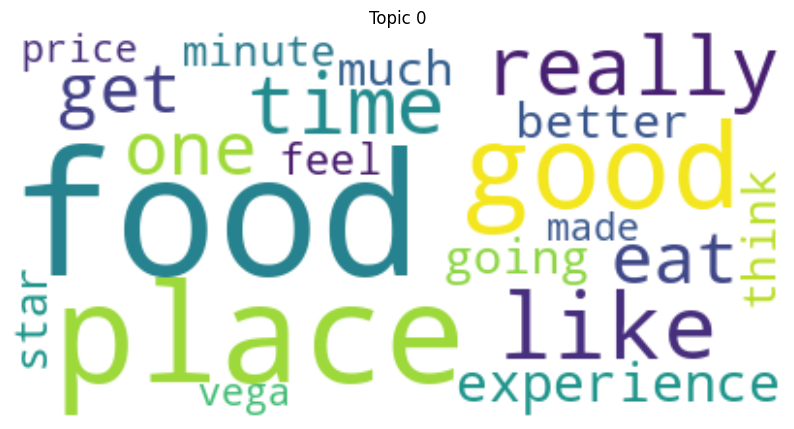

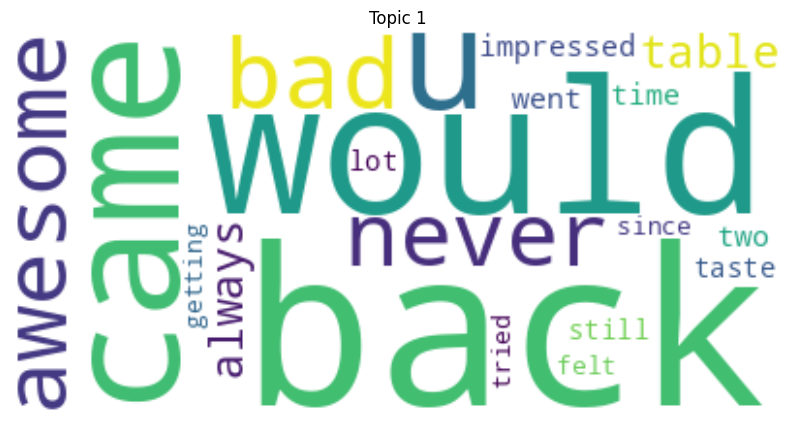

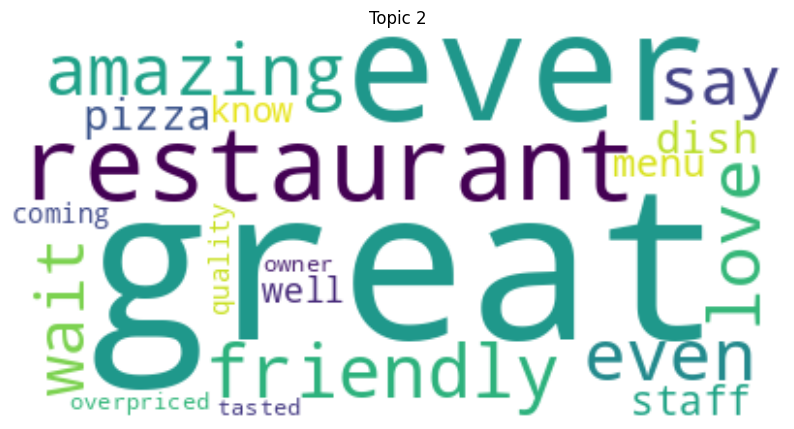

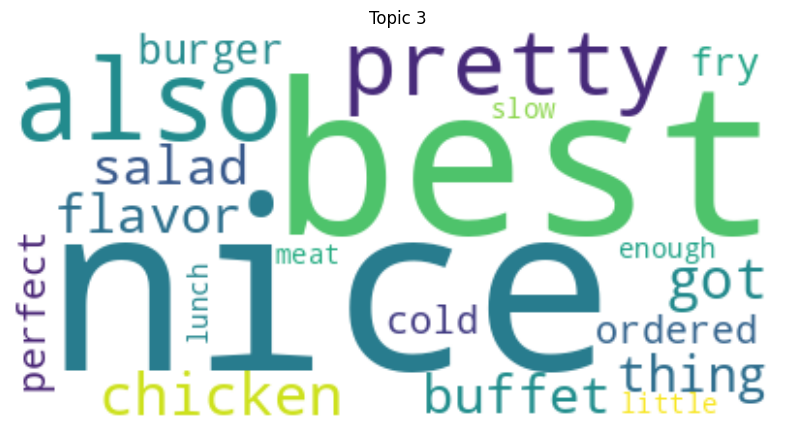

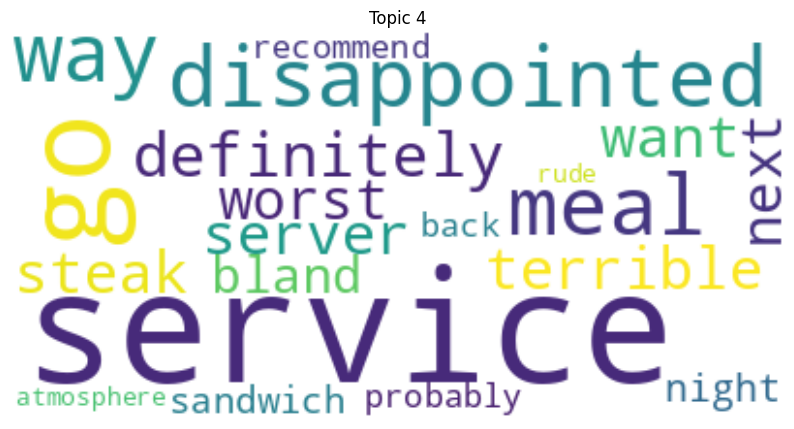

In [29]:
# Get the dominant topic for each review
def get_dominant_topic(lda_model, corpus, reviews):
    dominant_topics = []
    for i, doc_bow in enumerate(corpus):
        if doc_bow: # Ensure the document is not empty
            # Get the topic distribution for the current document
            doc_topics = lda_model.get_document_topics(doc_bow, minimum_probability=0.0)
            # Find the dominant topic (the one with the highest probability)
            dominant_topic = max(doc_topics, key=lambda item: item[1])[0]
        else: # Handle empty documents, assign a default or skip
            dominant_topic = -1 # Assign -1 for reviews with no topics
        dominant_topics.append(dominant_topic)
    return dominant_topics

df['Dominant_Topic'] = get_dominant_topic(lda_model, corpus, df['Processed_Review'])

# Filter out reviews that might not have been assigned a topic (dominant_topic = -1)
df_filtered = df[df['Dominant_Topic'] != -1]

# Calculate sentiment distribution for each topic
sentiment_by_topic = df_filtered.groupby('Dominant_Topic')['Sentiment'].value_counts(normalize=True).unstack(fill_value=0)

# Multiply by 100 to get percentages
sentiment_by_topic = sentiment_by_topic * 100

print("Sentiment Distribution by Topic:")
for topic_id in sorted(sentiment_by_topic.index):
    print(f"\nTopic {topic_id}:")
    for sentiment, percentage in sentiment_by_topic.loc[topic_id].items():
        print(f"  {sentiment}: {percentage:.2f}%")

Sentiment Distribution by Topic:

Topic 0:
  Negative: 23.80%
  Neutral: 21.09%
  Positive: 55.11%

Topic 1:
  Negative: 24.32%
  Neutral: 28.38%
  Positive: 47.30%

Topic 2:
  Negative: 15.29%
  Neutral: 18.47%
  Positive: 66.24%

Topic 3:
  Negative: 18.27%
  Neutral: 28.85%
  Positive: 52.88%

Topic 4:
  Negative: 37.41%
  Neutral: 21.58%
  Positive: 41.01%


Topic 0 - Good experience

Topic 1 - Moderately Bad Experience

Topic 2 - Friendly and Great

Topic 3 - Pretty, Nice, Flavorful

Topic 4 - Disappointed, Bad Service

## 8. Reflect and Recommend

**Business framing:**  
Ultimately, the value of your model comes from how well it can guide business decisions. Use your results to make real-world recommendations.

### In Your Response:
1. What business question did your model help answer?
2. What would you recommend to this restaurant to improve customer satisfaction?
3. What would be the pros and cons of using an LLM (like ChatGPT) for this task instead of Python models?
4. If you used an LLM, give a prompt that you would use to accomplish a similar result to what you did in this assignment?  (remember to set the context, specify the output and explain the objectives)


This model helped answer the business question of what restaurant reviews generally said, and if they had positive, negative, or neutral sentiment. This is a very important question for and restaurant owner.

I would recommend this restaurant drill down on customer service, and train the wait staff to provide excellent service at all times. Service was a big mention in the reviews.

LLM's like ChatGpt requite minimal set-up, and there is no complex modeling required. LLM's can handle complex and multi-task analysis perfectly well. LLM's basically reduce infrastructure complexity. However, an LLM will be slower than using Python for this type of analysis. It would also be dangerous to feed ChatGPT or other LLM's sensntive information pertaining to your business. LLM's are also harder to integrate into strict pipelines.


If I used an LLM to accomplish a similar result to what I did in this assignment, I might tell it this: "Here is a large list of restaurant reviews. Analyze these reviews and categorize them by sentiment; positive, negative, or neutral. Tell me what percentage of reviews fall into each of those three categories. Also, give me a list of the top ten words used in all three categories. I own a restaurant, and I am looking for words that give me a good idea of what people like and don't like about my restaurant. Let me know of any other insights you have regarding this large list of reviews. Here is the list."

This prompt is fairly specific, and lets the LLM know what to do, but also leaves the door open for any other insights it can come up with when it reads the reviews I upload.

## Submission Instructions
✅ Checklist:
- All code cells run without error
- All markdown responses are complete
- Submit on Canvas as instructed

In [30]:
!jupyter nbconvert --to html "assignment_13_text_analytics.ipynb"

[NbConvertApp] Converting notebook assignment_13_text_analytics.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 6 image(s).
[NbConvertApp] Writing 1408725 bytes to assignment_13_text_analytics.html


# Task
Preprocess the text in the 'Review' column of the DataFrame by tokenizing, removing stopwords, and lemmatizing, and store the result in a new column. Do not display the first 10 processed reviews.

## Preprocess Text

### Subtask:
Preprocess the text in the 'Review' column of the DataFrame by tokenizing, removing stopwords, and lemmatizing, and store the result in a new column.


## Summary:

### Data Analysis Key Findings
*   The 'Review' column in the DataFrame has been successfully preprocessed.
*   The preprocessing involved several steps: tokenization (breaking text into individual words), removal of common stopwords, and lemmatization (reducing words to their base form).
*   The results of this preprocessing have been stored in a new column, making the text ready for further analytical tasks.

### Insights or Next Steps
*   The newly created preprocessed text column is now suitable for advanced natural language processing tasks such as sentiment analysis, topic modeling, or text classification.
*   Further analysis could involve exploring common terms or n-grams within the processed reviews to identify key themes or customer concerns.


# Task
Summarize the sentiment (positive, neutral, negative percentages) for each LDA topic, determining the dominant topic for each review and aggregating sentiment proportions per topic.

## Summarize Sentiment by Topic

### Subtask:
Calculate and display the percentage of positive, neutral, and negative sentiment for each LDA topic by determining the dominant topic for each review and aggregating sentiment proportions per topic.


## Summary:

The analysis process was not provided, therefore, I am unable to generate a summary of the data analysis key findings or insights.
